# Challenges Week 11

Now that you have some experience with NLP and visualizing text, it's time for you to apply your knowledge.

## Dataset
Still remember the dataset about food in Hsinchu? Let's work with that. The first cell will load the dataset for you.

## Challenges

1. Count the word frequency in the description (介紹). What are the most frequent terms?
2. Make a word cloud
3. Write a streamlit app. With an option (widget) for me to choose how many top terms to plot.

**Bonus**: Can you write a Streamlit app that: lets me upload a CSV, choose the text column, and generate a word cloud?

In [1]:
import pandas as pd
food = pd.read_csv("food.csv")
food.head()

,名稱,網址,電話,行政區,AreaCode,地址,介紹
0,新竹水潤餅,https://www.facebook.com/profile.php?id=100063...,(03)5243708,北區,10018020,成功路326號,外地人乍聽「水潤餅」的名字時，會以為是潤餅的一種，其實水潤餅和潤餅完全是兩回事。它是許多新竹...
1,彭成珍餅舖,https://www.pengpastry.com.tw/,(03)5224877,北區,10018020,西安街5巷21號,推薦菜色：花生糖派對(原味、綜合堅果)、竹塹餅、麻糬紅豆Q餅、新竹椪餅，若非熟門熟路，一般人...
2,淵明餅舖,http://www.yuanming.com.tw/,0952170115,北區,10018020,中山路112號,推薦菜色：肉燥水蒸鹹蛋糕、風味芋頭餅、冰立方吐司；滷肉燥搭鬆軟蛋糕，在口中會撞出怎樣的火花？...
3,新復珍商行,https://www.hfj.com.tw/,(03)5222205,北區,10018020,北門街6號,推薦菜色：竹塹餅、柴梳餅、核桃酥餅、水蒸蛋糕、美祿柑、綠豆椪，有一種餅，作家焦桐說它的滋味是...
4,光華冰果店,https://www.facebook.com/kwanhua35,(03)5322318,北區,10018020,光華東街35號,推薦菜色：綜合冰、四果湯、銀耳蓮子湯，在許多新竹人心中，「光華」是記憶中陪伴成長的一家老冰菓...


In [2]:
!pip install jieba
!pip install pathlib
!pip install nltk wordcloud matplotlib pandas
!pip install wordcloud

In [3]:
import re
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import nltk
import pandas as pd
from wordcloud import STOPWORDS as WORDCLOUD_STOPWORDS
from wordcloud import WordCloud
import jieba # This one is for Chinese tokenization

In [8]:
import contextlib, io

resources = {
    "punkt": "tokenizers/punkt",
    "punkt_tab": "tokenizers/punkt_tab",
    "stopwords": "corpora/stopwords",
    "wordnet": "corpora/wordnet",
    "omw-1.4": "corpora/omw-1.4",
    "averaged_perceptron_tagger_eng": "taggers/averaged_perceptron_tagger_eng",
}

for package, lookup_path in resources.items():
    try:
        nltk.data.find(lookup_path)
    except LookupError:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            nltk.download(package, quiet=True, raise_on_error=False)

In [4]:
csv_path = 'food.csv'
df = pd.read_csv(csv_path)
df.head()

,名稱,網址,電話,行政區,AreaCode,地址,介紹
0,新竹水潤餅,https://www.facebook.com/profile.php?id=100063...,(03)5243708,北區,10018020,成功路326號,外地人乍聽「水潤餅」的名字時，會以為是潤餅的一種，其實水潤餅和潤餅完全是兩回事。它是許多新竹...
1,彭成珍餅舖,https://www.pengpastry.com.tw/,(03)5224877,北區,10018020,西安街5巷21號,推薦菜色：花生糖派對(原味、綜合堅果)、竹塹餅、麻糬紅豆Q餅、新竹椪餅，若非熟門熟路，一般人...
2,淵明餅舖,http://www.yuanming.com.tw/,0952170115,北區,10018020,中山路112號,推薦菜色：肉燥水蒸鹹蛋糕、風味芋頭餅、冰立方吐司；滷肉燥搭鬆軟蛋糕，在口中會撞出怎樣的火花？...
3,新復珍商行,https://www.hfj.com.tw/,(03)5222205,北區,10018020,北門街6號,推薦菜色：竹塹餅、柴梳餅、核桃酥餅、水蒸蛋糕、美祿柑、綠豆椪，有一種餅，作家焦桐說它的滋味是...
4,光華冰果店,https://www.facebook.com/kwanhua35,(03)5322318,北區,10018020,光華東街35號,推薦菜色：綜合冰、四果湯、銀耳蓮子湯，在許多新竹人心中，「光華」是記憶中陪伴成長的一家老冰菓...


In [16]:
custom_terms = ['水潤餅', '柴梳餅', '竹塹餅', '銀耳蓮子湯', '麻糬紅豆Q餅', '水蒸蛋糕']
for term in custom_terms:
    jieba.add_word(term)
with open("chinese_stopwords.txt", "r", encoding="utf-8") as f:
    STOPWORDS = f.read().splitlines()

In [10]:
df['clean_text'] = df['介紹'].fillna('').astype(str)
df['clean_text']

0     外地人乍聽「水潤餅」的名字時，會以為是潤餅的一種，其實水潤餅和潤餅完全是兩回事。它是許多新竹...
1     推薦菜色：花生糖派對(原味、綜合堅果)、竹塹餅、麻糬紅豆Q餅、新竹椪餅，若非熟門熟路，一般人...
2     推薦菜色：肉燥水蒸鹹蛋糕、風味芋頭餅、冰立方吐司；滷肉燥搭鬆軟蛋糕，在口中會撞出怎樣的火花？...
3     推薦菜色：竹塹餅、柴梳餅、核桃酥餅、水蒸蛋糕、美祿柑、綠豆椪，有一種餅，作家焦桐說它的滋味是...
4     推薦菜色：綜合冰、四果湯、銀耳蓮子湯，在許多新竹人心中，「光華」是記憶中陪伴成長的一家老冰菓...
5     推薦菜色：陽春麵、榨菜肉絲麵、滷味拼盤，樹林頭麵店是時代的座標，讓過去的記憶降落，讓現在的人...
6     推薦菜色：牛肉麵、牛肉乾麵、豬骨湯腸麵、各式滷味，「揭家牛肉麵」開業已六十餘年，是新竹知名老...
7     推薦菜色：原味甜不辣、鹽酥甜不辣、綜合飯、牛蒡甜不辣，深受在地人喜愛的「漁香甜不辣」，以新鮮...
8     推薦菜色：古早味蚵仔煎、烤排骨、紅燒魚皮、黑米糕，位於民富國小對面的竹樂食堂，是老牌熱炒店，...
9     推薦菜色：藥膳燒酒烏骨雞、金錢蝦、里肌糖醋肉、墨魚香腸，台灣到處都有燒酒雞，但新竹市「蔡記雞...
10    推薦菜色：魯肉飯、摃丸湯、肉羹湯，深夜時分，城隍廟口前，一家亮著橘黃小燈的攤位上，食客來來往...
11    推薦菜色：蚵仔大腸麵線、三福麵線、牛肉麵線，乾淨衛生的環境、舒適自在的氛圍與道地台灣家鄉味，...
12    推薦菜色：招牌薑母雞、狀元雞，「婆婆做薑母烏骨雞幫我做月子、補身體，因緣際會成就了這家店。」...
13    推薦菜色：鴨肉湯麵、炒鴨血、燻鴨肉，厚實的木砧板上不斷傳來剁鴨肉的低沉咚咚聲，暱稱「二姊」的...
14    推薦菜色：火鍋、炒沙茶牛肉麵、祖傳特製沙茶醬、牛雜湯，從城隍廟口轉到廟旁的西門市場，沿著小巷...
15    推薦菜色：廣東粥、皮蛋瘦肉粥，在中正路與水田街轉角處，毫不起眼的「余家金城廣東粥」，外觀雖老...
16    推薦菜色：肉粿、蚵仔嗲、米糕、蒜頭，城北街的午後是熱鬧的，午茶時間，總開始有人聚湧在一家不起...
17    推薦菜色：鴨香飯、燻鴨切盤、炒鴨血，2016年以一道鴨香飯入選「竹好呷」，深獲媒體推

In [11]:
df['clean_text'] = df['clean_text'].str.replace(r'\\n', ' ', regex=True)
df['clean_text']

0     外地人乍聽「水潤餅」的名字時，會以為是潤餅的一種，其實水潤餅和潤餅完全是兩回事。它是許多新竹...
1     推薦菜色：花生糖派對(原味、綜合堅果)、竹塹餅、麻糬紅豆Q餅、新竹椪餅，若非熟門熟路，一般人...
2     推薦菜色：肉燥水蒸鹹蛋糕、風味芋頭餅、冰立方吐司；滷肉燥搭鬆軟蛋糕，在口中會撞出怎樣的火花？...
3     推薦菜色：竹塹餅、柴梳餅、核桃酥餅、水蒸蛋糕、美祿柑、綠豆椪，有一種餅，作家焦桐說它的滋味是...
4     推薦菜色：綜合冰、四果湯、銀耳蓮子湯，在許多新竹人心中，「光華」是記憶中陪伴成長的一家老冰菓...
5     推薦菜色：陽春麵、榨菜肉絲麵、滷味拼盤，樹林頭麵店是時代的座標，讓過去的記憶降落，讓現在的人...
6     推薦菜色：牛肉麵、牛肉乾麵、豬骨湯腸麵、各式滷味，「揭家牛肉麵」開業已六十餘年，是新竹知名老...
7     推薦菜色：原味甜不辣、鹽酥甜不辣、綜合飯、牛蒡甜不辣，深受在地人喜愛的「漁香甜不辣」，以新鮮...
8     推薦菜色：古早味蚵仔煎、烤排骨、紅燒魚皮、黑米糕，位於民富國小對面的竹樂食堂，是老牌熱炒店，...
9     推薦菜色：藥膳燒酒烏骨雞、金錢蝦、里肌糖醋肉、墨魚香腸，台灣到處都有燒酒雞，但新竹市「蔡記雞...
10    推薦菜色：魯肉飯、摃丸湯、肉羹湯，深夜時分，城隍廟口前，一家亮著橘黃小燈的攤位上，食客來來往...
11    推薦菜色：蚵仔大腸麵線、三福麵線、牛肉麵線，乾淨衛生的環境、舒適自在的氛圍與道地台灣家鄉味，...
12    推薦菜色：招牌薑母雞、狀元雞，「婆婆做薑母烏骨雞幫我做月子、補身體，因緣際會成就了這家店。」...
13    推薦菜色：鴨肉湯麵、炒鴨血、燻鴨肉，厚實的木砧板上不斷傳來剁鴨肉的低沉咚咚聲，暱稱「二姊」的...
14    推薦菜色：火鍋、炒沙茶牛肉麵、祖傳特製沙茶醬、牛雜湯，從城隍廟口轉到廟旁的西門市場，沿著小巷...
15    推薦菜色：廣東粥、皮蛋瘦肉粥，在中正路與水田街轉角處，毫不起眼的「余家金城廣東粥」，外觀雖老...
16    推薦菜色：肉粿、蚵仔嗲、米糕、蒜頭，城北街的午後是熱鬧的，午茶時間，總開始有人聚湧在一家不起...
17    推薦菜色：鴨香飯、燻鴨切盤、炒鴨血，2016年以一道鴨香飯入選「竹好呷」，深獲媒體推

In [12]:
df['clean_text'] = df['clean_text'].str.replace(r'[^\u4e00-\u9fffA-Za-z\s]', ' ', regex=True)
df['clean_text']

0     外地人乍聽 水潤餅 的名字時 會以為是潤餅的一種 其實水潤餅和潤餅完全是兩回事 它是許多新竹...
1     推薦菜色 花生糖派對 原味 綜合堅果  竹塹餅 麻糬紅豆Q餅 新竹椪餅 若非熟門熟路 一般人...
2     推薦菜色 肉燥水蒸鹹蛋糕 風味芋頭餅 冰立方吐司 滷肉燥搭鬆軟蛋糕 在口中會撞出怎樣的火花 ...
3     推薦菜色 竹塹餅 柴梳餅 核桃酥餅 水蒸蛋糕 美祿柑 綠豆椪 有一種餅 作家焦桐說它的滋味是...
4     推薦菜色 綜合冰 四果湯 銀耳蓮子湯 在許多新竹人心中  光華 是記憶中陪伴成長的一家老冰菓...
5     推薦菜色 陽春麵 榨菜肉絲麵 滷味拼盤 樹林頭麵店是時代的座標 讓過去的記憶降落 讓現在的人...
6     推薦菜色 牛肉麵 牛肉乾麵 豬骨湯腸麵 各式滷味  揭家牛肉麵 開業已六十餘年 是新竹知名老...
7     推薦菜色 原味甜不辣 鹽酥甜不辣 綜合飯 牛蒡甜不辣 深受在地人喜愛的 漁香甜不辣  以新鮮...
8     推薦菜色 古早味蚵仔煎 烤排骨 紅燒魚皮 黑米糕 位於民富國小對面的竹樂食堂 是老牌熱炒店 ...
9     推薦菜色 藥膳燒酒烏骨雞 金錢蝦 里肌糖醋肉 墨魚香腸 台灣到處都有燒酒雞 但新竹市 蔡記雞...
10    推薦菜色 魯肉飯 摃丸湯 肉羹湯 深夜時分 城隍廟口前 一家亮著橘黃小燈的攤位上 食客來來往...
11    推薦菜色 蚵仔大腸麵線 三福麵線 牛肉麵線 乾淨衛生的環境 舒適自在的氛圍與道地台灣家鄉味 ...
12    推薦菜色 招牌薑母雞 狀元雞  婆婆做薑母烏骨雞幫我做月子 補身體 因緣際會成就了這家店  ...
13    推薦菜色 鴨肉湯麵 炒鴨血 燻鴨肉 厚實的木砧板上不斷傳來剁鴨肉的低沉咚咚聲 暱稱 二姊 的...
14    推薦菜色 火鍋 炒沙茶牛肉麵 祖傳特製沙茶醬 牛雜湯 從城隍廟口轉到廟旁的西門市場 沿著小巷...
15    推薦菜色 廣東粥 皮蛋瘦肉粥 在中正路與水田街轉角處 毫不起眼的 余家金城廣東粥  外觀雖老...
16    推薦菜色 肉粿 蚵仔嗲 米糕 蒜頭 城北街的午後是熱鬧的 午茶時間 總開始有人聚湧在一家不起...
17    推薦菜色 鴨香飯 燻鴨切盤 炒鴨血     年以一道鴨香飯入選 竹好呷  深獲媒體推

In [13]:
raw_tokens = [jieba.lcut(x) for x in df['clean_text']]
df['raw_tokens'] = raw_tokens
df['raw_tokens']

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\user\AppData\Local\Temp\jieba.cache
Loading model cost 1.177 seconds.
Prefix dict has been built successfully.


0     [外地人, 乍, 聽,  , 水潤餅,  , 的, 名字, 時,  , 會以, 為, 是, ...
1     [推薦, 菜色,  , 花生糖, 派, 對,  , 原味,  , 綜合, 堅果,  ,  ,...
2     [推薦, 菜色,  , 肉燥, 水蒸, 鹹, 蛋糕,  , 風味芋, 頭餅,  , 冰, 立...
3     [推薦, 菜色,  , 竹塹餅,  , 柴, 梳餅,  , 核桃, 酥餅,  , 水蒸, 蛋...
4     [推薦, 菜色,  , 綜合冰,  , 四果湯,  , 銀耳蓮子湯,  , 在, 許多, 新...
5     [推薦, 菜色,  , 陽春, 麵,  , 榨菜, 肉絲, 麵,  , 滷, 味, 拼, 盤...
6     [推薦, 菜色,  , 牛肉, 麵,  , 牛肉乾, 麵,  , 豬骨, 湯腸, 麵,  ,...
7     [推薦, 菜色,  , 原味, 甜不辣,  , 鹽, 酥, 甜不辣,  , 綜合飯,  , ...
8     [推薦, 菜色,  , 古早, 味, 蚵, 仔, 煎,  , 烤, 排骨,  , 紅燒, 魚...
9     [推薦, 菜色,  , 藥膳, 燒酒, 烏骨雞,  , 金錢, 蝦,  , 里, 肌, 糖醋...
10    [推薦, 菜色,  , 魯肉, 飯,  , 摃, 丸湯,  , 肉羹, 湯,  , 深夜, ...
11    [推薦, 菜色,  , 蚵, 仔大腸, 麵, 線,  , 三福, 麵, 線,  , 牛肉, ...
12    [推薦, 菜色,  , 招牌, 薑, 母雞,  , 狀元, 雞,  ,  , 婆婆, 做, ...
13    [推薦, 菜色,  , 鴨肉湯, 麵,  , 炒, 鴨, 血,  , 燻, 鴨, 肉,  ,...
14    [推薦, 菜色,  , 火鍋,  , 炒, 沙茶, 牛肉, 麵,  , 祖傳, 特, 製, ...
15    [推薦, 菜色,  , 廣東, 粥,  , 皮蛋, 瘦肉粥,  , 在, 中正路, 與, 水...
16    [推薦, 菜色,  , 肉, 粿,  , 蚵, 仔, 嗲,  , 米糕,  , 蒜頭,  ,...
17    [推薦, 菜色,  , 鴨香飯,  , 燻, 鴨切, 盤,  , 炒, 鴨, 血, 

In [19]:
df['clean_tokens'] = [
    [token.strip().lower() for token in token_list]
    for token_list in df['raw_tokens']
]
df['clean_tokens']

0     [外地人, 乍, 聽, , 水潤餅, , 的, 名字, 時, , 會以, 為, 是, 潤餅,...
1     [推薦, 菜色, , 花生糖, 派, 對, , 原味, , 綜合, 堅果, , , 竹塹餅,...
2     [推薦, 菜色, , 肉燥, 水蒸, 鹹, 蛋糕, , 風味芋, 頭餅, , 冰, 立方, ...
3     [推薦, 菜色, , 竹塹餅, , 柴, 梳餅, , 核桃, 酥餅, , 水蒸, 蛋糕, ,...
4     [推薦, 菜色, , 綜合冰, , 四果湯, , 銀耳蓮子湯, , 在, 許多, 新竹人, ...
5     [推薦, 菜色, , 陽春, 麵, , 榨菜, 肉絲, 麵, , 滷, 味, 拼, 盤, ,...
6     [推薦, 菜色, , 牛肉, 麵, , 牛肉乾, 麵, , 豬骨, 湯腸, 麵, , 各式,...
7     [推薦, 菜色, , 原味, 甜不辣, , 鹽, 酥, 甜不辣, , 綜合飯, , 牛蒡, ...
8     [推薦, 菜色, , 古早, 味, 蚵, 仔, 煎, , 烤, 排骨, , 紅燒, 魚皮, ...
9     [推薦, 菜色, , 藥膳, 燒酒, 烏骨雞, , 金錢, 蝦, , 里, 肌, 糖醋, 肉...
10    [推薦, 菜色, , 魯肉, 飯, , 摃, 丸湯, , 肉羹, 湯, , 深夜, 時分, ...
11    [推薦, 菜色, , 蚵, 仔大腸, 麵, 線, , 三福, 麵, 線, , 牛肉, 麵, ...
12    [推薦, 菜色, , 招牌, 薑, 母雞, , 狀元, 雞, , , 婆婆, 做, 薑, 母...
13    [推薦, 菜色, , 鴨肉湯, 麵, , 炒, 鴨, 血, , 燻, 鴨, 肉, , 厚實,...
14    [推薦, 菜色, , 火鍋, , 炒, 沙茶, 牛肉, 麵, , 祖傳, 特, 製, 沙茶,...
15    [推薦, 菜色, , 廣東, 粥, , 皮蛋, 瘦肉粥, , 在, 中正路, 與, 水田, ...
16    [推薦, 菜色, , 肉, 粿, , 蚵, 仔, 嗲, , 米糕, , 蒜頭, , 城北, ...
17    [推薦, 菜色, , 鴨香飯, , 燻, 鴨切, 盤, , 炒, 鴨, 血, , ,

In [20]:
df['tokens'] = [
    [
        token
        for token in token_list
        if token != '' and token not in STOPWORDS
    ]
    for token_list in df['clean_tokens']
]

df['tokens']

0     [外地人, 乍, 聽, 水潤餅, 名字, 時, 會以, 潤餅, 一種, 水潤餅, 潤餅, 完...
1     [推薦, 菜色, 花生糖, 派, 原味, 綜合, 堅果, 竹塹餅, 麻, 糬, 紅, 豆, ...
2     [推薦, 菜色, 肉燥, 水蒸, 鹹, 蛋糕, 風味芋, 頭餅, 冰, 立方, 吐司, 滷,...
3     [推薦, 菜色, 竹塹餅, 柴, 梳餅, 核桃, 酥餅, 水蒸, 蛋糕, 美祿, 柑, 綠豆...
4     [推薦, 菜色, 綜合冰, 四果湯, 銀耳蓮子湯, 許多, 新竹人, 心中, 光華, 記憶,...
5     [推薦, 菜色, 陽春, 麵, 榨菜, 肉絲, 麵, 滷, 味, 拼, 盤, 樹林頭, 麵,...
6     [推薦, 菜色, 牛肉, 麵, 牛肉乾, 麵, 豬骨, 湯腸, 麵, 滷, 味, 揭家, 牛...
7     [推薦, 菜色, 原味, 甜不辣, 鹽, 酥, 甜不辣, 綜合飯, 牛蒡, 甜不辣, 深受,...
8     [推薦, 菜色, 古早, 味, 蚵, 仔, 煎, 烤, 排骨, 紅燒, 魚皮, 黑米, 糕,...
9     [推薦, 菜色, 藥膳, 燒酒, 烏骨雞, 金錢, 蝦, 里, 肌, 糖醋, 肉, 墨魚, ...
10    [推薦, 菜色, 魯肉, 飯, 摃, 丸湯, 肉羹, 湯, 深夜, 時分, 城隍, 廟, 口...
11    [推薦, 菜色, 蚵, 仔大腸, 麵, 線, 三福, 麵, 線, 牛肉, 麵, 線, 乾淨衛...
12    [推薦, 菜色, 招牌, 薑, 母雞, 狀元, 雞, 婆婆, 做, 薑, 母, 烏骨雞, 幫...
13    [推薦, 菜色, 鴨肉湯, 麵, 炒, 鴨, 血, 燻, 鴨, 肉, 厚實, 木, 砧板, ...
14    [推薦, 菜色, 火鍋, 炒, 沙茶, 牛肉, 麵, 祖傳, 特, 製, 沙茶, 醬, 牛雜...
15    [推薦, 菜色, 廣東, 粥, 皮蛋, 瘦肉粥, 中正路, 水田, 街, 轉角處, 起眼, ...
16    [推薦, 菜色, 肉, 粿, 蚵, 仔, 嗲, 米糕, 蒜頭, 城北, 街, 午後是, 熱鬧...
17    [推薦, 菜色, 鴨香飯, 燻, 鴨切, 盤, 炒, 鴨, 血, 年, 一道, 鴨香

In [28]:
all_tokens = []
for tokens in df['tokens']:
    for token in tokens:
        all_tokens.append(token)
        
top_terms = pd.DataFrame(Counter(all_tokens).most_common(20), columns=['term', 'count'])
top_terms

,term,count
0,麵,124
1,製,88
2,後,73
3,闆,67
4,年,67
5,說,64
6,吃,57
7,咖啡,56
8,鴨,54
9,口感,53


In [22]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def setup_cjk_font():
    candidates = [
        'Noto Sans CJK TC',
        'Noto Sans CJK SC',
        'Noto Sans CJK JP',
        'Microsoft JhengHei',
        'PingFang TC',
        'SimHei',
        'Arial Unicode MS'
    ]

    available_fonts = fm.fontManager.ttflist

    for font in candidates:
        for f in available_fonts:
            if font == f.name:
                plt.rcParams['font.family'] = 'sans-serif'
                plt.rcParams['font.sans-serif'] = [font]
                plt.rcParams['axes.unicode_minus'] = False

                print(f'Using font: {font}')
                print(f'Font path: {f.fname}')

                return f.fname

    print('No CJK font found by matplotlib.')
    return None

font_path = setup_cjk_font()

Using font: Microsoft JhengHei
Font path: C:\Windows\Fonts\msjh.ttc


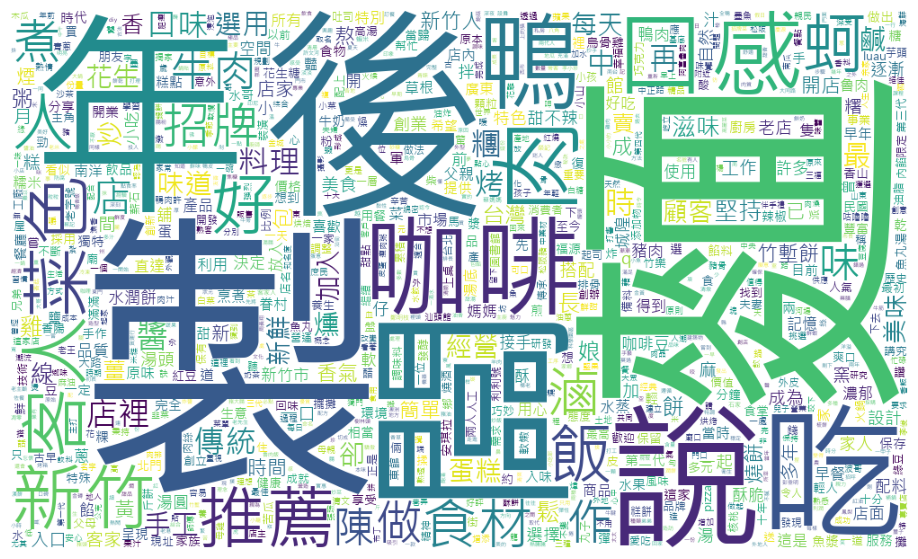

In [30]:
top_terms = pd.DataFrame(Counter(all_tokens).most_common(1000), columns=['term', 'count'])

wc = WordCloud(
    font_path=font_path,
    width=1000,
    height=600,
    background_color='white',
    max_words=1000,
    collocations=False
).generate_from_frequencies(dict(zip(top_terms['term'], top_terms['count'])))

plt.figure(figsize=(12, 7))
plt.imshow(wc)
plt.axis('off')
plt.show()

In [33]:
import streamlit as st
import pandas as pd
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

st.title("新竹水潤餅文字雲")

num_words = st.slider(
    "選擇文字數量",
    min_value=1,
    max_value=1000,
    value=100,
    step=1
)

filtered_terms = top_terms.head(num_words)

freq_dict = dict(zip(
    filtered_terms['term'],
    filtered_terms['count']
))

font_path = "msjh.ttc"  

wc = WordCloud(
    font_path=font_path,
    width=1000,
    height=600,
    background_color='white',
    collocations=False
).generate_from_frequencies(freq_dict)

fig, ax = plt.subplots(figsize=(12, 7))

ax.imshow(wc)
ax.axis('off')
st.pyplot(fig)

2026-05-07 15:01:35.432 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 15:01:35.432 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 15:01:35.434 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 15:01:35.434 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 15:01:35.434 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 15:01:35.438 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 15:01:35.438 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 15:01:35.439 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()